# Yellowstone Ecosystem EDA
**Datasets:**
- Northern herd elk population (1923–2024) — `Default_Dataset_clean.csv`
- Wolf population & pack counts (1995–2024) — `wolf.ods`
- Definite, probable, and possible elk kills by wolves (1995-2024) — `elk_kills.ods`
- April snowpack / SWE at Lupine Creek, WY (1938–2025) — `lupine_creek_data__full_.txt`

**Research question:** After 1968, the National Park Service (NPS) adopted a policy of "natural regulation" in Yellowstone, leading to a marked increase in elk population. In 1995, the Yellowstone Wolf Project reintroduced wolves to Yellowstone National Park, which was followed by a significant decline in elk herd numbers. This analysis explores the relationship between elk population, wolf predation, and snowpack.

## 1. Imports & configuration

In [839]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import scipy.stats as stats
import numpy as np
from statsmodels.formula.api import ols

# Consistent style throughout
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

## 2. Load & clean data

### 2.1 Elk population data

In [840]:
elk = pd.read_csv('data/Default_Dataset_clean.csv')
elk.columns = ['year', 'elk_population']
elk = elk.sort_values('year').reset_index(drop=True)

print('Elk population dataset')
print(f'  Years: {elk.year.min()}–{elk.year.max()} | Rows: {len(elk)}')
if len(elk) != elk.year.max() - elk.year.min() + 1:
    print(f'  Missing years: coverage is not consecutive; gaps exist')
elk.head()

Elk population dataset
  Years: 1923–2024 | Rows: 69
  Missing years: coverage is not consecutive; gaps exist


,year,elk_population
0,1923,11637
1,1925,12494
2,1927,12519
3,1928,8967
4,1929,9194


### 2.2 Wolf population data

In [841]:
wolves = pd.read_excel('data/wolf.ods', engine='odf')
wolves.columns = ['year', 'wolf_population', 'packs']
wolves = wolves.sort_values('year').reset_index(drop=True)

print('Wolf population dataset')
print(f'  Years: {wolves.year.min()}–{wolves.year.max()} | Rows: {len(wolves)}')
if len(wolves) != wolves.year.max() - wolves.year.min() + 1:
    print(f'  Missing years: coverage is not consecutive; gaps exist')
wolves.head()

Wolf population dataset
  Years: 1995–2024 | Rows: 30


,year,wolf_population,packs
0,1995,21,3
1,1996,51,9
2,1997,86,9
3,1998,112,11
4,1999,118,11


### 2.3 Wolf-elk predation data

In [842]:
elk_kills = pd.read_excel('data/elk_kills.ods', engine='odf')
elk_kills.columns = ['year', 'elk_kills']
elk_kills = elk_kills.sort_values('year').reset_index(drop=True)

print('Wolf-elk predation dataset')
print(f'  Years: {elk_kills.year.min()}–{elk_kills.year.max()} | Rows: {len(pred)}')
if len(elk_kills) != elk_kills.year.max() - elk_kills.year.min() + 1:
    print(f'  Missing years: coverage is not consecutive; gaps exist')
elk_kills.head()

Wolf-elk predation dataset
  Years: 1995–2024 | Rows: 100


,year,elk_kills
0,1995,43
1,1996,124
2,1997,257
3,1998,197
4,1999,276


### 2.4 April snowpack data

In [843]:
# Ignore header comments
snow = pd.read_csv(
    'data/lupine_creek_data__full_.txt',
    comment='#'
)

# Rename verbose columns
snow.columns = ['date', 'swe_in', 'snow_depth_in']

# Parse year out of 'Apr YYYY' date strings
snow['year'] = pd.to_datetime(snow['date'], format='%b %Y').dt.year

# Drop Date column
snow = snow.drop(columns=['date'])

# Reorder columns and sort by year
snow = snow[['year', 'swe_in', 'snow_depth_in']]
snow = snow.sort_values('year').reset_index(drop=True)

print('Snowpack dataset (April SWE & depth, Lupine Creek WY)')
print(f'  Years: {snow.year.min()}–{snow.year.max()} | Rows: {len(snow)}')
print(f'  Missing values:\n{snow.isnull().sum()}')
snow.head()

Snowpack dataset (April SWE & depth, Lupine Creek WY)
  Years: 1938–2025 | Rows: 88
  Missing values:
year             0
swe_in           1
snow_depth_in    3
dtype: int64


,year,swe_in,snow_depth_in
0,1938,11.8,39.0
1,1939,8.6,32.0
2,1940,7.0,22.0
3,1941,5.4,23.0
4,1942,7.6,30.0


## 3. Summary Statistics

### 3.1 Elk population

In [844]:
print(elk['elk_population'].describe().round(0))

count       69.0
mean      9400.0
std       3939.0
min       3224.0
25%       6121.0
50%       8841.0
75%      11763.0
max      19118.0
Name: elk_population, dtype: float64


### 3.2 Wolf population

In [845]:
print(wolves[['wolf_population', 'packs']].describe().round(0))

       wolf_population  packs
count             30.0   30.0
mean             119.0   12.0
std               48.0    5.0
min               21.0    3.0
25%               96.0    9.0
50%              108.0   11.0
75%              124.0   13.0
max              272.0   31.0


### 3.3 Wolf-elk predation

In [846]:
print(elk_kills[['elk_kills']].describe().round(0))

       elk_kills
count       30.0
mean       199.0
std         93.0
min         43.0
25%        124.0
50%        195.0
75%        271.0
max        463.0


### 3.4 Snowpack (April SWE, inches)

In [847]:
print(snow['swe_in'].describe().round(2))

count    87.00
mean      8.69
std       3.46
min       0.00
25%       6.60
50%       8.60
75%      10.85
max      17.40
Name: swe_in, dtype: float64


## 4. Overview Plots

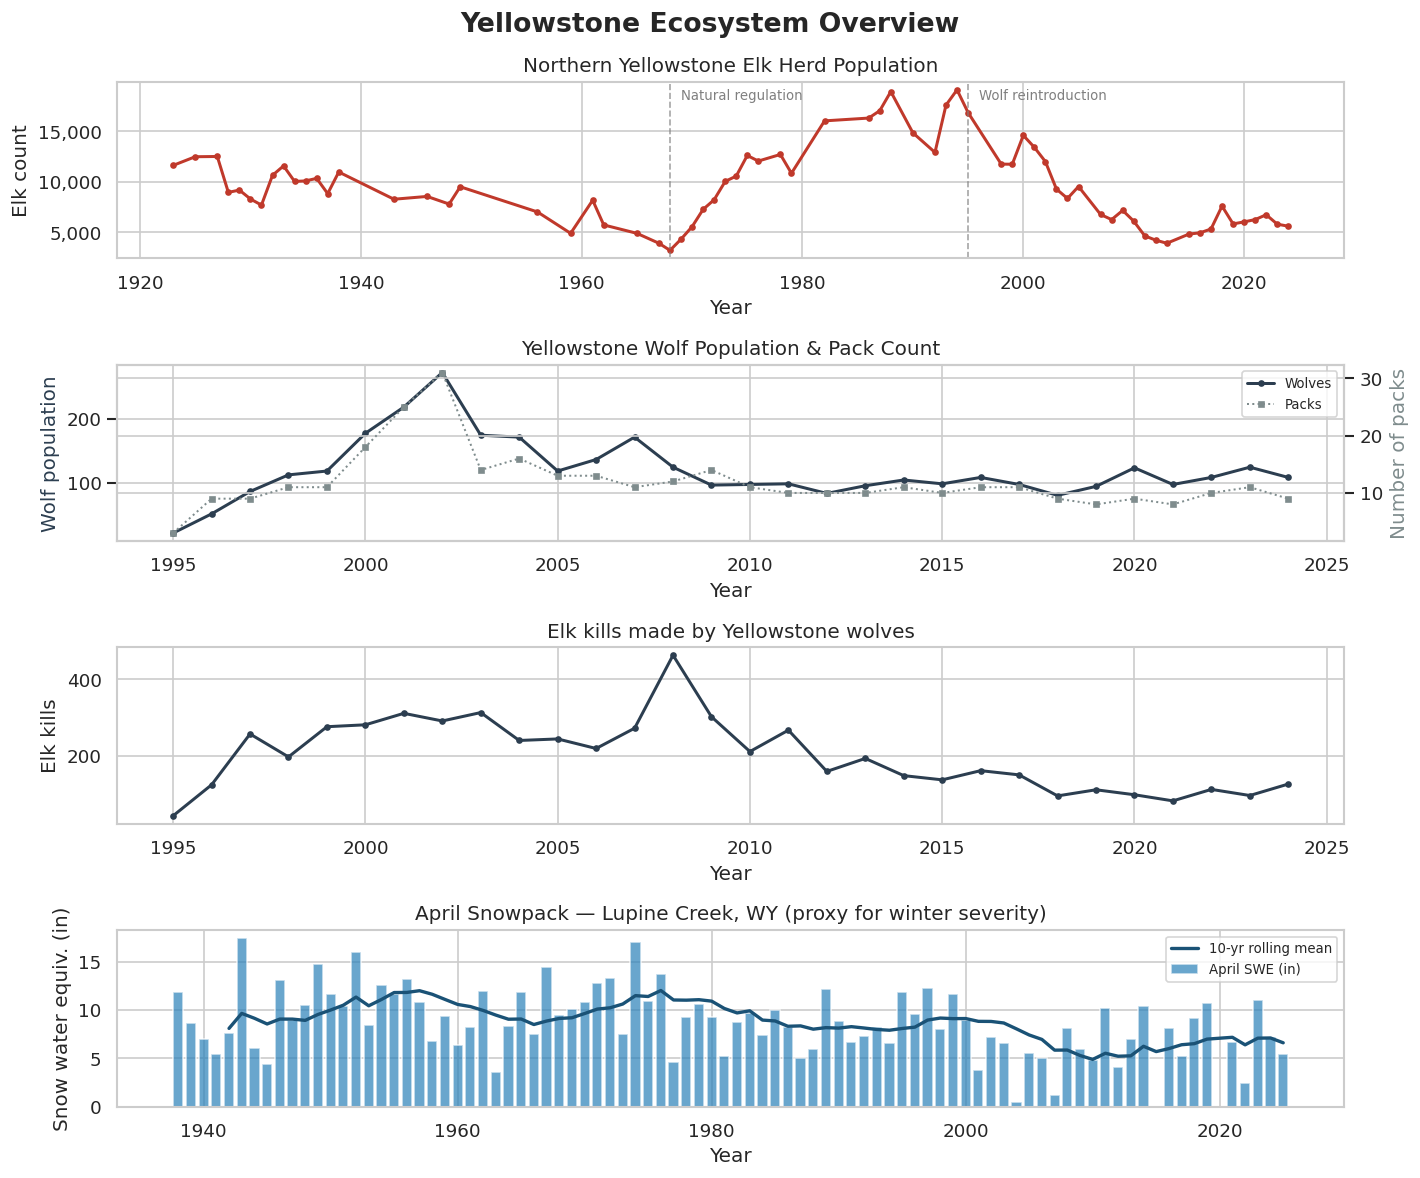

In [848]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=False)
fig.suptitle('Yellowstone Ecosystem Overview', fontsize=16, fontweight='bold')

REINTRO_YEAR = 1995
NATURAL_REG_YEAR = 1968

# --- Elk ---
ax = axes[0]
ax.plot(elk['year'], elk['elk_population'], color='#c0392b', linewidth=1.8, marker='o', markersize=3)
ax.axvline(REINTRO_YEAR, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.axvline(NATURAL_REG_YEAR, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.set_ylabel('Elk count')
ax.set_title('Northern Yellowstone Elk Herd Population')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.annotate('Wolf reintroduction',
            xy=(REINTRO_YEAR, elk['elk_population'].max()),
            xytext=(REINTRO_YEAR + 1, elk['elk_population'].max() * 0.95),
            fontsize=8, color='gray')
ax.annotate('Natural regulation',
            xy=(NATURAL_REG_YEAR, elk['elk_population'].max()),
            xytext=(NATURAL_REG_YEAR + 1, elk['elk_population'].max() * 0.95),
            fontsize=8, color='gray')

# --- Wolves ---
ax = axes[1]
ax2 = ax.twinx()
ax.plot(wolves['year'], wolves['wolf_population'], color='#2c3e50', linewidth=1.8, marker='o', markersize=3, label='Wolves')
ax2.plot(wolves['year'], wolves['packs'], color='#7f8c8d', linewidth=1.2, linestyle=':', marker='s', markersize=3, label='Packs')
ax.set_ylabel('Wolf population', color='#2c3e50')
ax2.set_ylabel('Number of packs', color='#7f8c8d')
ax.set_title('Yellowstone Wolf Population & Pack Count')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
legend = ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper right')
legend.set_zorder(10)

# --- Wolf-elk predation
ax = axes[2]
ax.plot(elk_kills['year'], elk_kills['elk_kills'], color='#2c3e50', linewidth=1.8, marker='o', markersize=3)
ax.set_ylabel('Elk kills')
ax.set_title('Elk kills made by Yellowstone wolves')

# --- Snowpack ---
ax = axes[3]
ax.bar(snow['year'], snow['swe_in'], color='#2980b9', alpha=0.7, width=0.8, label='April SWE (in)')
# Rolling 10-year mean to show trend
snow_sorted = snow.dropna(subset=['swe_in'])
rolling_swe = snow_sorted.set_index('year')['swe_in'].rolling(10, min_periods=5).mean()
ax.plot(rolling_swe.index, rolling_swe.values, color='#1a5276', linewidth=2, label='10-yr rolling mean')
#ax.axvline(REINTRO_YEAR, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.set_ylabel('Snow water equiv. (in)')
ax.set_title('April Snowpack — Lupine Creek, WY (proxy for winter severity)')
ax.legend(fontsize=8)

for ax in axes:
    ax.set_xlabel('Year')

plt.tight_layout()
plt.savefig('outputs/01_overview.png', bbox_inches='tight')
plt.show()

#### Comments

The elk population plot shows two distinct trend reversals, each of which reflects a policy shift. Until 1968, the NPS regularly hunted and trapped elk to manage their numbers. This process ended in 1968 when the NPS adopted a policy of "natural regulation," under which ecological processes were allowed to function free of direct human intervention. However, bereft of natural predators to regulate it, the elk population exploded, increasing nearly fourfold within the following decade. In 1995, wolves were reintroduced to the Yellowstone ecosystem, and elk numbers declined to pre-1968 levels over the following years.

## 5. Elk population before vs. after 1995 (wolf reintroduction)
For the purpose of this analysis, only years from 1968 onward will be considered to compare the effects of natural regulation before and after wolf reintroduction.

### 5.1 Comparing mean/variance of pre-1995 and post-1995 elk populations

In [849]:
elk_working = elk.copy()
elk_working = elk_working[elk_working['year'] >= 1968] # compare elk population only after natural regulation policy
#elk_working = elk_working[~elk_working['year'].between(1995, 2000)] # uncomment to exclude transitional period following wolf reintroduction
elk_working['era'] = elk_working['year'].apply(
    lambda y: 'Pre-1995' if y < 1995 else 'Post-1995'
)

pre  = elk_working.loc[elk_working['era'] == 'Pre-1995',  'elk_population']
post = elk_working.loc[elk_working['era'] == 'Post-1995', 'elk_population']

t_stat, t_p = stats.ttest_ind(pre, post, equal_var=False)
lev_stat, lev_p = stats.levene(pre, post)

print('=== Pre-1995 ===')
print(f'  n={len(pre)}, mean={pre.mean():,.0f}, std={pre.std():,.0f}, '
      f'min={pre.min():,}, max={pre.max():,}')
print('=== Post-1995 ===')
print(f'  n={len(post)}, mean={post.mean():,.0f}, std={post.std():,.0f}, '
      f'min={post.min():,}, max={post.max():,}')
print(f'Welch\'s t-test (means): t={t_stat:.3f}, p={t_p:.4f}')
print(f'Levene test (variances):  W={lev_stat:.3f}, p={lev_p:.4f}')

=== Pre-1995 ===
  n=19, mean=12,126, std=4,838, min=3,224, max=19,118
=== Post-1995 ===
  n=26, mean=7,919, std=3,468, min=3,929, max=16,864
Welch's t-test (means): t=3.232, p=0.0029
Levene test (variances):  W=2.534, p=0.1188


#### Comments

At α = 0.05, the mean elk population declined significantly after wolf reintroduction, averaging 2,376 fewer elk (p = 0.0029). Although the Levene test found equal variances between eras (p = 0.1188), Welch's t-test was used as the more conservative choice.

### 5.2 Visualizing pre-1995 and post-1995 elk population distributions

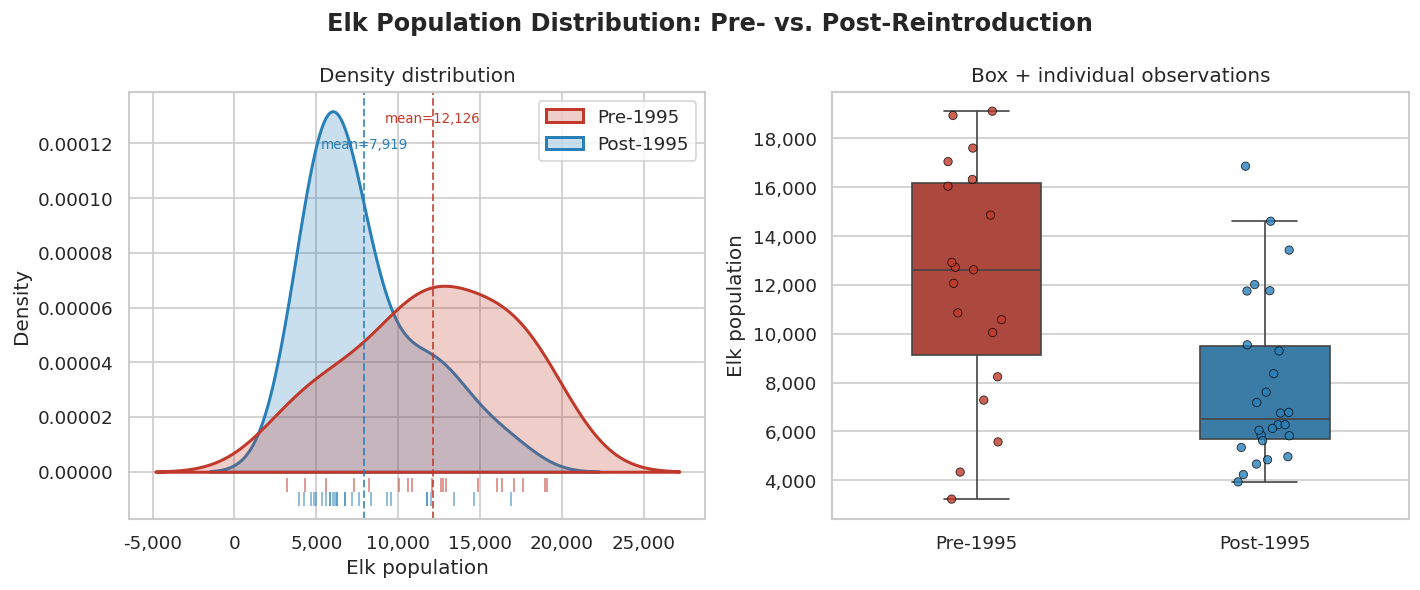

In [850]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Elk Population Distribution: Pre- vs. Post-Reintroduction', fontweight='bold')

ERA_COLORS = {'Pre-1995': '#c0392b', 'Post-1995': '#2980b9'}

# Left: overlapping KDE + rug
ax = axes[0]
for era, group in elk_working.groupby('era'):
    sns.kdeplot(group['elk_population'], ax=ax, label=era,
                color=ERA_COLORS[era], fill=True, alpha=0.25, linewidth=1.8)
    ax.plot(group['elk_population'], np.zeros(len(group)) - 0.000005 * (1 if era == 'Pre-1995' else 2),
            '|', color=ERA_COLORS[era], markersize=8, alpha=0.6)
ax.axvline(pre.mean(),  color='#c0392b', linestyle='--', linewidth=1.2, alpha=0.8)
ax.axvline(post.mean(), color='#2980b9', linestyle='--', linewidth=1.2, alpha=0.8)
ax.set_xlabel('Elk population')
ax.set_ylabel('Density')
ax.set_title('Density distribution')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()
handles, labels = ax.get_legend_handles_labels()
order = [labels.index('Pre-1995'), labels.index('Post-1995')]
ax.legend([handles[i] for i in order], [labels[i] for i in order])
ax.annotate(f'mean={pre.mean():,.0f}',  xy=(pre.mean(),  ax.get_ylim()[1]*0.92),
            ha='center', fontsize=8, color='#c0392b')
ax.annotate(f'mean={post.mean():,.0f}', xy=(post.mean(), ax.get_ylim()[1]*0.85),
            ha='center', fontsize=8, color='#2980b9')

# Right: box + strip
ax = axes[1]
sns.boxplot(data=elk_working, x='era', y='elk_population', ax=ax,
            palette=ERA_COLORS, hue='era', width=0.45, order=['Pre-1995', 'Post-1995'],
            flierprops=dict(marker=''))
sns.stripplot(data=elk_working, x='era', y='elk_population', ax=ax,
              palette=ERA_COLORS, hue='era', order=['Pre-1995', 'Post-1995'],
              size=5, alpha=0.8, jitter=True,
              linewidth=0.5, edgecolor='black')
ax.set_xlabel('')
ax.set_ylabel('Elk population')
ax.set_title('Box + individual observations')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('outputs/06_distribution_comparison.png', bbox_inches='tight')
plt.show()

#### Comments

Although the Levene test found no significant difference in population variance between eras, both the KDE and box plots suggest a noticeably tighter spread post-1995. This is likely a power issue: the transitional period immediately following reintroduction keeps early post-1995 values elevated, obscuring the eventual reduction in variance. After excluding observations between 1995 and 2000, the Levene test does find a significant difference (p = 0.0044).

### 5.3 Structural break analysis

In [851]:
elk_working['post'] = (elk_working['year'] >= 1995).astype(int) # convert year to integer
elk_working['year_centered'] = elk_working['year'] - 1995 # center at breakpoint
elk_working['year_post'] = elk_working['year_centered'] * elk_working['post'] # 0 for year <= 1995; 1 at 1996, 2 at 1997, etc.

# Restricted model: one trend line for the whole period
restricted = ols('elk_population ~ year_centered', data=elk_working).fit()

# Unrestricted model: intercept + slope allowed to differ post-1995
unrestricted = ols('elk_population ~ year_centered + post + year_post', data=elk_working).fit()

#### 5.3.1 Chow test

In [852]:
rss_r = restricted.ssr
rss_u = unrestricted.ssr
n     = len(elk_working)
k     = 2   # number of parameters added to unrestricted model

# Manually compute Chow F-statistic/p-value
chow_f = ((rss_r - rss_u) / k) / (rss_u / (n - (2 + k)))
chow_p = stats.f.sf(chow_f, dfn=k, dfd=n - (2 + k))

print('=== Chow Test ===')
print(f'  RSS restricted:   {rss_r:,.0f}')
print(f'  RSS unrestricted: {rss_u:,.0f}')
print(f'  F({k}, {n - 2*k}) = {chow_f:.3f},  p = {chow_p:.4f}')

=== Chow Test ===
  RSS restricted:   787,283,589
  RSS unrestricted: 201,719,830
  F(2, 41) = 59.509,  p = 0.0000


#### 5.3.2 Visualizing structural break

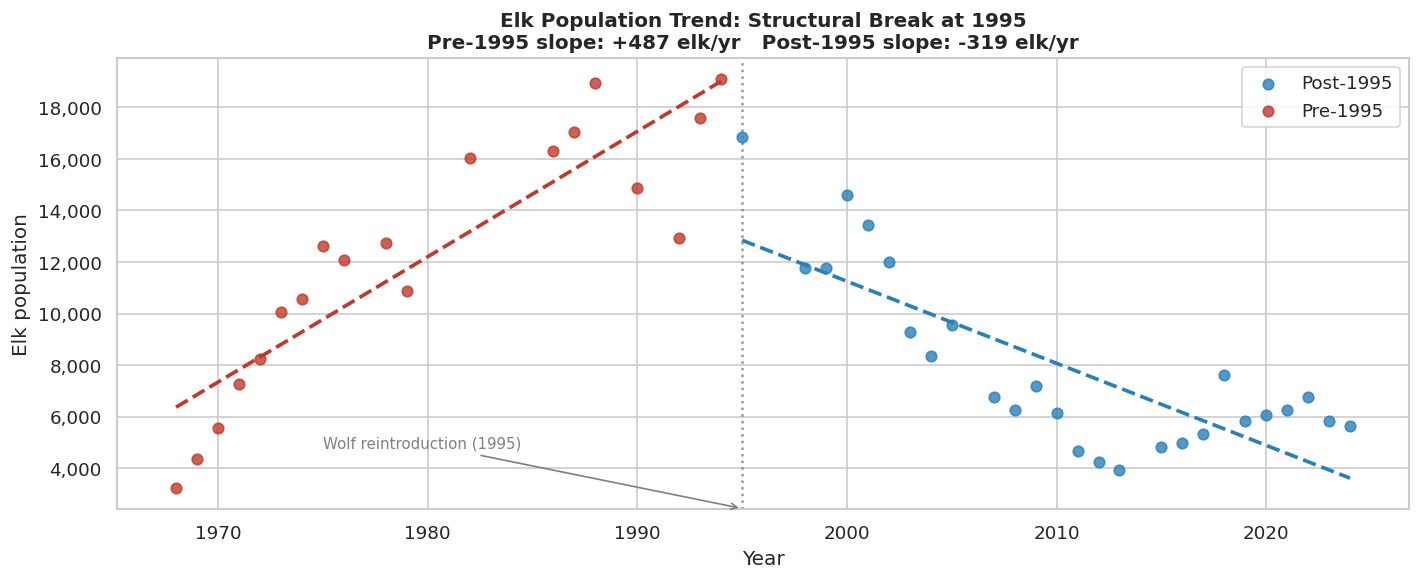

In [853]:
ERA_COLORS = {'Pre-1995': '#c0392b', 'Post-1995': '#2980b9'}
fig, ax = plt.subplots(figsize=(12, 5))

# Scatter points colored by era
for era, group in elk_working.groupby('era'):
    ax.scatter(group['year'], group['elk_population'],
               color=ERA_COLORS[era], s=40, alpha=0.8, label=era, zorder=3)

# Fitted lines from unrestricted model - predict over each era's year range
for era, color in ERA_COLORS.items():
    subset = elk_working[elk_working['era'] == era]
    yr_range = np.linspace(subset['year'].min(), subset['year'].max(), 100)
    yr_c = yr_range - 1995
    is_post = (yr_range >= 1995).astype(int)
    pred = (unrestricted.params['Intercept']
            + unrestricted.params['year_centered'] * yr_c
            + unrestricted.params['post'] * is_post
            + unrestricted.params['year_post'] * yr_c * is_post)
    ax.plot(yr_range, pred, color=color, linewidth=2.2, linestyle='--')

ax.axvline(1995, color='gray', linestyle=':', linewidth=1.5, alpha=0.8)
ax.annotate('Wolf reintroduction (1995)', xy=(1995, ax.get_ylim()[0]),
            xytext=(1975, elk_working['elk_population'].max() * 0.25),
            fontsize=9, color='gray',
            arrowprops=dict(arrowstyle='->', color='gray', lw=1))

pre_slope  = unrestricted.params['year_centered']
post_slope = unrestricted.params['year_centered'] + unrestricted.params['year_post']
ax.set_title(
    f'Elk Population Trend: Structural Break at 1995\n'
    f'Pre-1995 slope: {pre_slope:+.0f} elk/yr   '
    f'Post-1995 slope: {post_slope:+.0f} elk/yr   ',
    fontweight='bold'
)
ax.set_xlabel('Year')
ax.set_ylabel('Elk population')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()

plt.tight_layout()
plt.savefig('outputs/07_structural_break.png', bbox_inches='tight')
plt.show()

### Comments

The structural break analysis shows the magnitude of reversal following wolf introduction, going from an average annual increase of 487 elk to a decrease of 319. Note that it is unlikely that elk numbers will continue to decline at this rate, as recent decades show signs of stabilization around a new equilibrium of roughly 5,000.

## 8. Multiple regression: predicting elk from wolves + snowpack
A simple model is fitted to predict elk population using wolf presence and snowpack. Note that number of wolf packs was chosen as an indication of wolf presence over raw population count as it was found to produce the highest adjusted R². Including both terms did not improve the model due to strong multicollinearity. Unexpectedly, the number of elk killed by wolves was found to be an insignificant predictor of elk population and was omitted from the model.

In [854]:
# Merge all three on year, restrict to wolf era (data overlap)
merged = pd.merge(wolves[['year', 'wolf_population', 'packs']], elk[['year', 'elk_population']], on='year')
merged = pd.merge(merged, elk_kills[['year', 'elk_kills']], on='year')
merged = pd.merge(merged, snow[['year', 'swe_in']], on='year')
merged = merged.dropna()

print(f'Complete cases for regression: n={len(merged)}, years {merged.year.min()}–{merged.year.max()}')

model = ols('elk_population ~ packs + swe_in', data=merged).fit()
print(model.summary())

Complete cases for regression: n=25, years 1995–2024
                            OLS Regression Results                            
Dep. Variable:         elk_population   R-squared:                       0.256
Model:                            OLS   Adj. R-squared:                  0.188
Method:                 Least Squares   F-statistic:                     3.786
Date:                Mon, 18 May 2026   Prob (F-statistic):             0.0386
Time:                        18:31:04   Log-Likelihood:                -235.40
No. Observations:                  25   AIC:                             476.8
Df Residuals:                      22   BIC:                             480.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

### Comments

The number of wolf packs was found to be significant at α = 0.05 (p = 0.030), while SWE was found to be marginally insignificant. Furthermore, a Durbin-Watson statistic of 0.712 indicates a positive autocorrelation, which is unsurprising given the inherent autocorrelation of time series data: irrespective of external factors, the elk population of previous years will be a strong predictor of the current elk population.

## 9. Addressing autocorrelation

There are two common methods of addressing autocorrelated data:

- AR(1): Include a lagged term for elk population from the previous year
- First difference: Use change in elk population as the response rather than the raw elk population

In [855]:
# --- AR(1): add elk_{t-1} as a predictor ---
ar1_data = merged.copy()
ar1_data['elk_lag1'] = ar1_data['elk_population'].shift(1)
ar1_data   = ar1_data.dropna(subset=['elk_lag1', 'swe_in']).copy()
ar1_data = ar1_data.dropna()
print(f'AR(1)  dataset: n={len(ar1_data)}, {ar1_data.year.min()}–{ar1_data.year.max()}')

ar1_model = ols('elk_population ~ packs + swe_in + elk_lag1', data=ar1_data).fit()
print(ar1_model.summary())

AR(1)  dataset: n=24, 1998–2024
                            OLS Regression Results                            
Dep. Variable:         elk_population   R-squared:                       0.814
Model:                            OLS   Adj. R-squared:                  0.786
Method:                 Least Squares   F-statistic:                     29.15
Date:                Mon, 18 May 2026   Prob (F-statistic):           1.68e-07
Time:                        18:31:04   Log-Likelihood:                -205.98
No. Observations:                  24   AIC:                             420.0
Df Residuals:                      20   BIC:                             424.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    339.663

In [856]:
# --- First differences: response becomes annual change in elk ---
diff_data = merged.copy()
diff_data['elk_diff'] = diff_data['elk_population'].diff()
diff_data = diff_data.dropna(subset=['elk_diff', 'swe_in']).copy()
print(f'Diff dataset: n={len(diff_data)}, {diff_data.year.min()}–{diff_data.year.max()}')

diff_model = ols('elk_diff ~ packs + swe_in', data=diff_data).fit()
print(diff_model.summary())

Diff dataset: n=24, 1998–2024
                            OLS Regression Results                            
Dep. Variable:               elk_diff   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.090
Method:                 Least Squares   F-statistic:                   0.04598
Date:                Mon, 18 May 2026   Prob (F-statistic):              0.955
Time:                        18:31:04   Log-Likelihood:                -211.71
No. Observations:                  24   AIC:                             429.4
Df Residuals:                      21   BIC:                             433.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -225.4073 

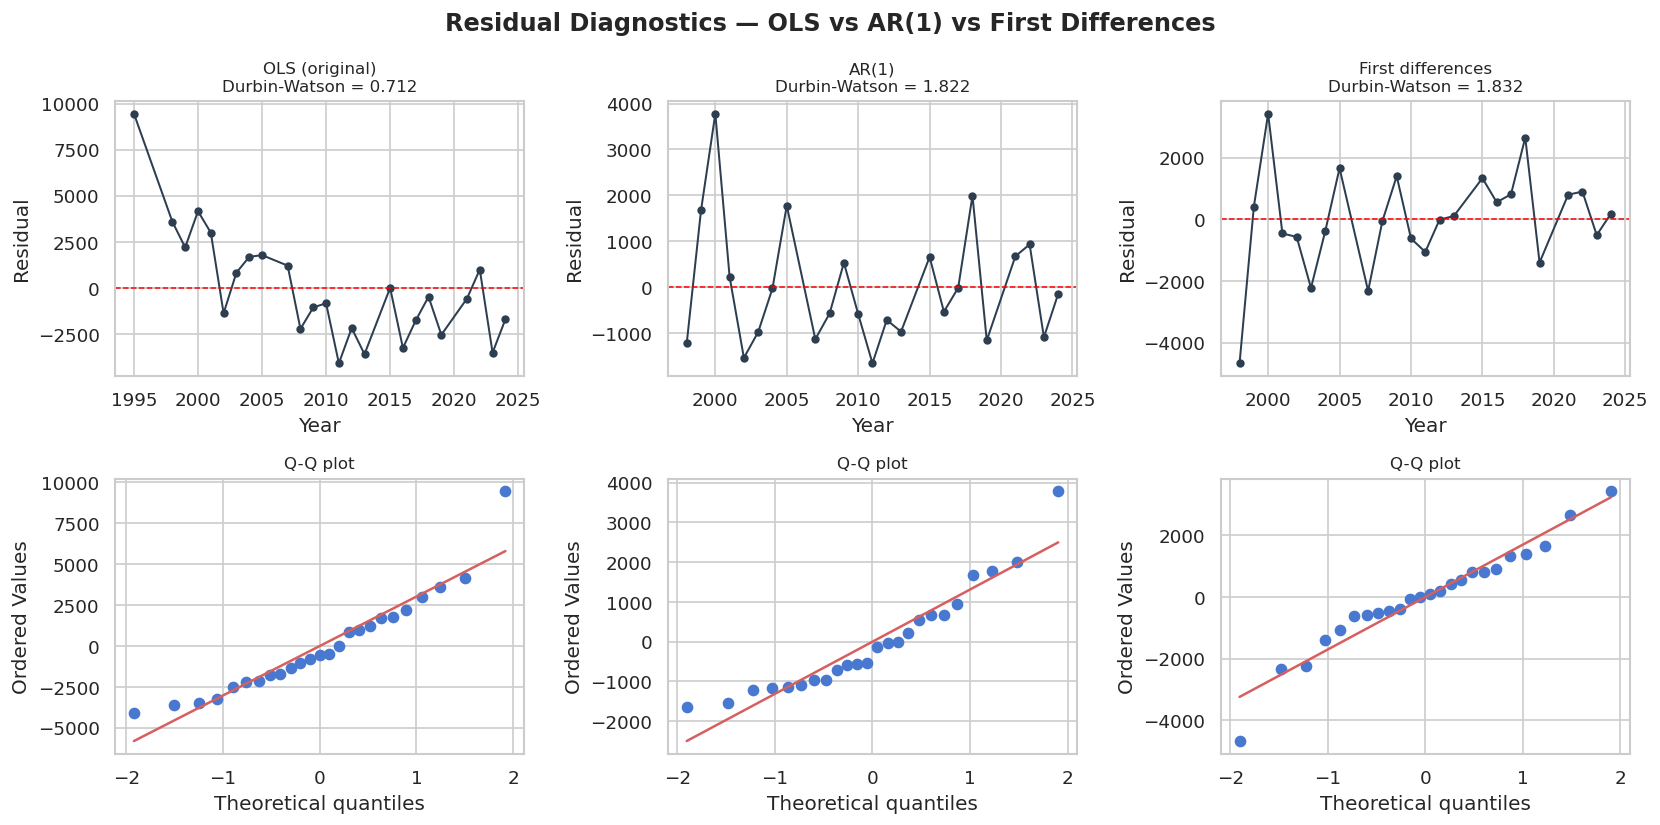

In [857]:
# Residual plots for all three models
from statsmodels.stats.stattools import durbin_watson

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.suptitle('Residual Diagnostics — OLS vs AR(1) vs First Differences', fontweight='bold')

models     = [model,    ar1_model,    diff_model]
years      = [merged['year'], ar1_data['year'], diff_data['year']]
subtitles  = ['OLS (original)', 'AR(1)', 'First differences']

for col, (mod, yr, title) in enumerate(zip(models, years, subtitles)):
    resid = mod.resid
    dw    = durbin_watson(resid)

    # Residuals over time
    ax = axes[0, col]
    ax.plot(yr, resid, marker='o', linewidth=1.2, markersize=4, color='#2c3e50')
    ax.axhline(0, color='red', linestyle='--', linewidth=0.9)
    ax.set_title(f'{title}\nDurbin-Watson = {dw:.3f}', fontsize=10)
    ax.set_xlabel('Year')
    ax.set_ylabel('Residual')

    # Q-Q plot
    ax = axes[1, col]
    stats.probplot(resid, plot=ax)
    ax.set_title('Q-Q plot', fontsize=10)

plt.tight_layout()
plt.savefig('outputs/05_residual_diagnostics.png', bbox_inches='tight')
plt.show()

### Comments

After correcting for autocorrelation, residual diagnostics improved substantially. Durbin-Watson values rose from ~0.7 to ~1.8 and non-normality was resolved. However, neither wolf packs nor April snowpack were significant predictors of year-to-year elk changes at α = 0.05 in either model, although wolf packs showed a marginal trend in the AR(1) model (p = 0.068).

The absence of a year-to-year predation signal is itself informative. Wolves killed approximately 200 elk per year on average, representing only 2–3% of the herd&mdash;well below the natural growth rate of roughly 500 elk per year observed from 1968 through 1994. Direct predation alone is therefore insufficient to explain the decline that followed reintroduction. This is consistent with the "landscape of fear" hypothesis, which proposes that wolf presence suppresses elk population through behavioral modification rather than direct predation: elk avoid high-risk foraging areas, expend more energy on vigilance, and experience lower reproductive fitness even in the absence of active predation.

## Conclusion

The northern Yellowstone elk herd exhibits three distinct demographic eras, each coinciding with a major policy shift. Prior to 1968, the herd was held at relatively low levels through active management. Following the cessation of culling, the population grew steadily at roughly 500 elk per year through the early 1990s, reaching historically high levels. Wolf reintroduction in 1995 coincides with a sharp reversal of that trend, with the herd declining at roughly 320 elk per year before showing signs of stabilization around a new equilibrium of 5,000&ndash;6,000 animals in recent years.

It bears emphasizing that none of this establishes causality. The analyses here identify correlations and structural breaks that coincide with known ecological events, but cannot rule out confounding factors, such as drought cycles, hunter harvest pressure, and broader climate trends. The regression models found no significant year-to-year relationship between wolf pack count, snowpack, and elk population change after correcting for autocorrelation, suggesting that whatever mechanism drives the post-1995 decline operates at a longer timescale than annual variation captures.

Several threads remain worth pursuing. Incorporating demographic kill data broken down by age class and season could help quantify whether wolf predation disproportionately targets reproductive-age females or calves, which would have outsized effects on herd growth rates. Adding a drought index such as the Palmer Drought Severity Index as a covariate would help disentangle climate effects from predation pressure. Finally, the apparent stabilization of the herd since roughly 2015 raises the question of whether a new predator-prey equilibrium has been reached.